# DSCI 552 - Homework 2

**Name:** Yiming Xiong  
**USC ID:** 1057091668

### Import section

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Set up the visualisation and display options
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

PREDICTORS = ["AT", "V", "AP", "RH"]
RESPONSE = "PE"
RANDOM_STATE = 42

# 1. Combined Cycle Power Plant Data Set

## 1(a) Download and Load the Data

Load `Sheet1`（Folds5x2_pp.xlsx） only. Confirm that the expected columns are present. Do not combine the five shuffled sheets.

In [20]:
DATA_PATH = "../data/Folds5x2_pp.xlsx"
SHEET_NAME = "Sheet1"

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
display(df.head())

,AT,V,AP,RH,PE
0,14.9600,41.7600,1024.0700,73.1700,463.2600
1,25.1800,62.9600,1020.0400,59.0800,444.3700
2,5.1100,39.4000,1012.1600,92.1400,488.5600
3,20.8600,57.3200,1010.2400,76.6400,446.4800
4,10.8200,37.5000,1009.2300,96.6200,473.9000


## 1(b) Exploring the Data

### 1(b)(i) statistical exploration

In [21]:
n_rows, n_cols = df.shape
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 9568
Number of columns: 5

Column names:
['AT', 'V', 'AP', 'RH', 'PE']


**Answer to 1(b)(i):**

Number of rows and columns ↑

Each row represents one observation of the power plant operating at
full load. The values in each row are hourly averages of the environmental
and operational measurements collected from the power plant.

The columns represent the following variables:

| Column | Role | Description | Unit |
|---|---|---|---|
| `AT` | Predictor | Hourly average ambient temperature | °C |
| `V` | Predictor | Exhaust vacuum | cm Hg |
| `AP` | Predictor | Ambient pressure | millibar |
| `RH` | Predictor | Relative humidity | % |
| `PE` | Response | Net hourly electrical energy output | MW |

Therefore, the first four columns are predictors, while `PE` is the
response variable that will be predicted.

### 1(b)(ii) Pairwise Scatterplots

Create pairwise scatterplots for all five variables, including the response `PE`. 

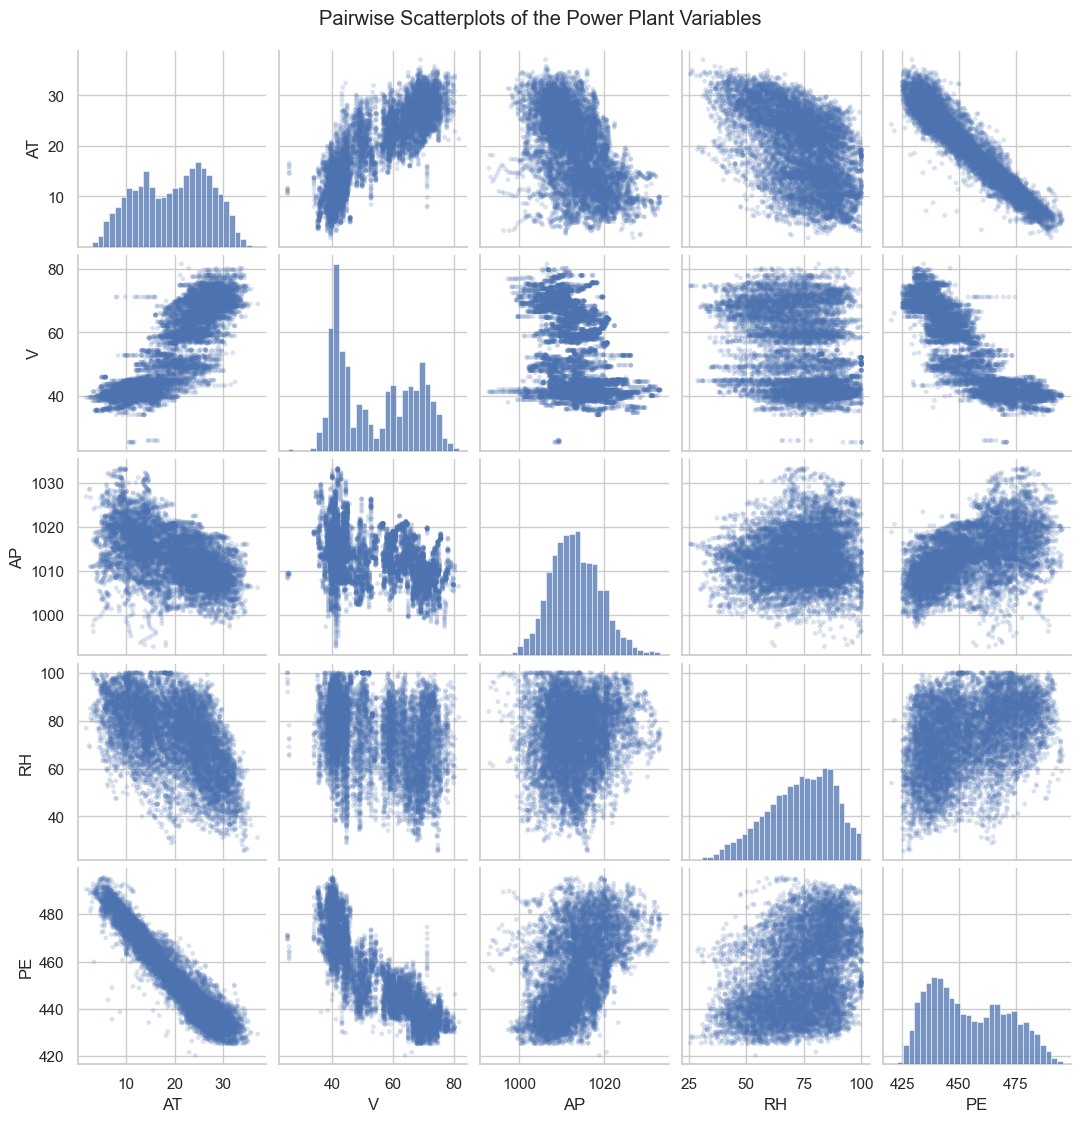

In [22]:
pair_grid = sns.pairplot(
    df,
    diag_kind="hist",
    height=2.2,
    plot_kws={"alpha": 0.2, "s": 12, "edgecolor": "none"},
    diag_kws={"bins": 30, "edgecolor": "white"}
)

pair_grid.figure.suptitle(
    "Pairwise Scatterplots of the Power Plant Variables",
    y=1.02
)

plt.show()

**Findings for 1(b)(ii):**  

`PE` has a very strong negative association with `AT`.
The higher the temperature, the usually lower the power generation. This is the most obvious and nearly linear relationship.

There is also a relatively strong negative correlation between `V` and `PE`.
When Exhaust Vacuum increases, PE usually decreases. The scatter plot shows a wide band-like structure, indicating that the relationship is not a completely simple linear relationship.

There is a weak positive correlation between `AP`.
Only an upward trend can be observed.

`RH` may have a positive correlation.
The upward trend exists only when there is a decrease in the lower right corner. The scatter points are very scattered, and using RH alone may not be able to accurately predict PE.

There are also associations among the predictors. In particular, `AT`
and `V` have a strong positive association, while `AT` is negatively
associated with both `AP` and `RH`. This suggests that multicollinearity
may need to be considered in a multiple regression model.

### 1(b)(iii) Descriptive Statistics

In [23]:
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)

summary_statistics = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "First Quartile (Q1)": q1,
    "Third Quartile (Q3)": q3,
    "Interquartile Range (IQR)": q3 - q1
})

summary_statistics.index.name = "Variable"

display(summary_statistics)

,Mean,Median,Range,First Quartile (Q1),Third Quartile (Q3),Interquartile Range (IQR)
Variable,,,,,,
AT,19.6512,20.3450,35.3000,13.5100,25.7200,12.2100
V,54.3058,52.0800,56.2000,41.7400,66.5400,24.8000
AP,1013.2591,1012.9400,40.4100,1009.1000,1017.2600,8.1600
RH,73.3090,74.9750,74.6000,63.3275,84.8300,21.5025
PE,454.3650,451.5500,75.5000,439.7500,468.4300,28.6800


## 1(c) Simple Linear Regression

Fit four separate models:

- `PE ~ AT`
- `PE ~ V`
- `PE ~ AP`
- `PE ~ RH`

For each model, report the coefficient, p-value, and model fit; discuss statistical significance; and use plots to evaluate the fitted relationship and possible outliers.

#### Build simple linear regression

In [24]:
simple_models = {
    predictor: smf.ols(
        f"{RESPONSE} ~ {predictor}",
        data=df
    ).fit()
    for predictor in PREDICTORS
}

simple_results = pd.DataFrame({
    predictor: {
        "Intercept": model.params["Intercept"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    }
    for predictor, model in simple_models.items()
}).T

simple_results.index.name = "Predictor"

display(simple_results)

,Intercept,Coefficient,P-value,R-squared
Predictor,,,,
AT,497.0341,-2.1713,0.0000,0.8989
V,517.8015,-1.1681,0.0000,0.7565
AP,-1055.2610,1.4899,0.0000,0.2688
RH,420.9618,0.4557,0.0000,0.1519


#### Draw the regression

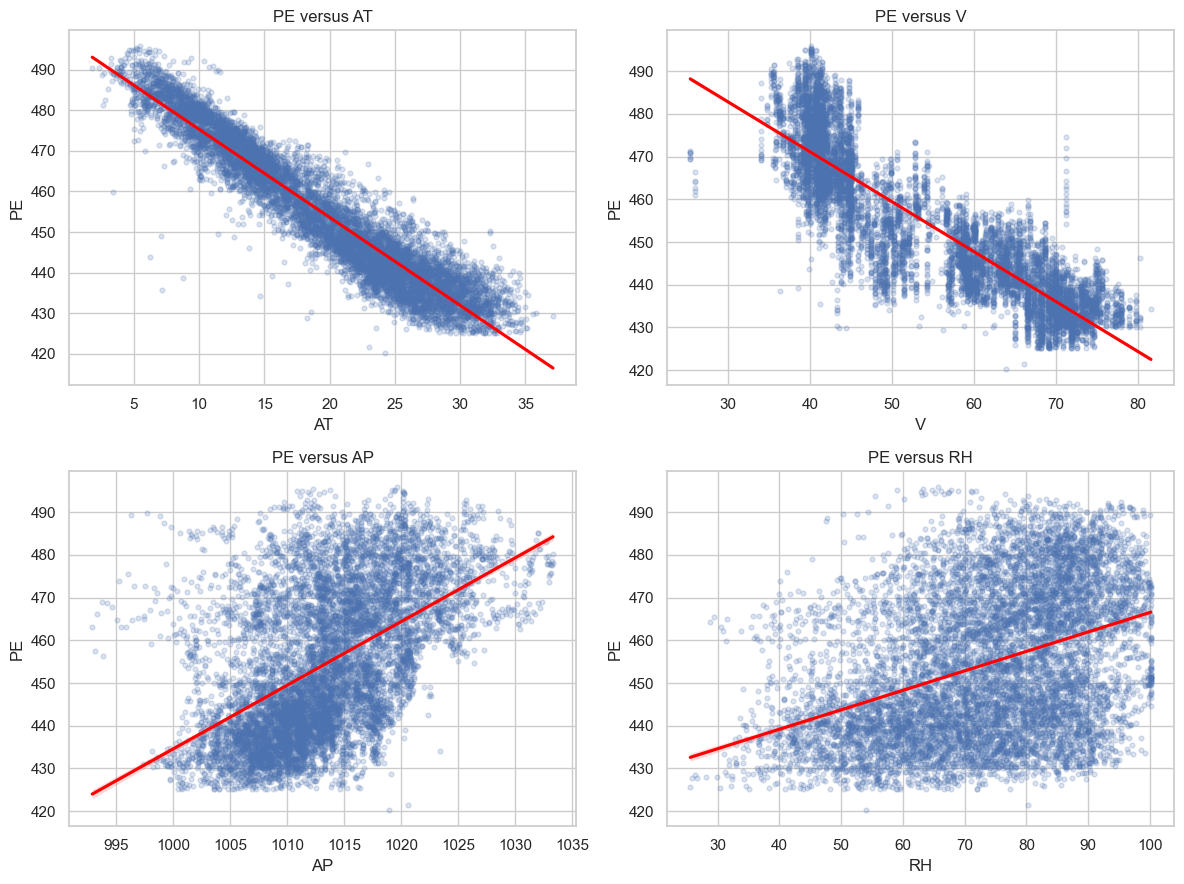

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(PREDICTORS, axes.flat):
    sns.regplot(
        data=df,
        x=predictor,
        y=RESPONSE,
        scatter_kws={"alpha": 0.2, "s": 12},
        line_kws={"color": "red"},
        ax=ax
    )

    ax.set_title(f"{RESPONSE} versus {predictor}")

plt.tight_layout()
plt.show()

**Answer to 1(c):**

All four predictors have statistically significant associations with
`PE`, since all slope p-values are less than 0.001.

`AT` and `V` have negative associations with `PE`. Their coefficients
are -2.1713 and -1.1681, respectively. `AT` produces the strongest
simple linear regression model, with an \(R^2\) of 0.8989, followed by
`V` with an \(R^2\) of 0.7565.

`AP` and `RH` have positive associations with `PE`. However, their
\(R^2\) values are only 0.2688 and 0.1519, respectively. Therefore,
although their associations are statistically significant, they have
much less explanatory power when used individually.

The plots show that the relationships involving `AT` and `V` are
stronger than those involving `AP` and `RH`. They also show curvature,
clusters, and unequal variation around the regression lines, suggesting
that some relationships may not be completely linear.

#### Check for outliers

In [26]:
outlier_results = []

for predictor, model in simple_models.items():
    influence = model.get_influence()

    studentized_residuals = influence.resid_studentized_internal
    cooks_distance = influence.cooks_distance[0]

    outlier_count = np.sum(np.abs(studentized_residuals) > 3)

    outlier_results.append({
        "Predictor": predictor,
        "|Studentized Residual| > 3": outlier_count,
        "Percentage": 100 * outlier_count / len(df),
        "Maximum Cook's Distance": cooks_distance.max()
    })

outlier_results = pd.DataFrame(outlier_results).set_index("Predictor")

display(outlier_results)

,|Studentized Residual| > 3,Percentage,Maximum Cook's Distance
Predictor,,,
AT,42,0.4390,0.0143
V,33,0.3449,0.0032
AP,29,0.3031,0.0082
RH,2,0.0209,0.0021


**Answer to 1(c):**  

If the Studentized Residual is greater than 3, it indicates that the actual PE value differs from the model's predicted value by more than approximately 3 standard deviations. These observations are considered potential outliers.

- The `AT` model has 42 potential outliers;
- The `V` model has 33;
- The `AP` model has approximately 29 or 30;
- The `RH` model has 2.
However, their proportions in the 9,568 data points are all very small.
Cook's distance measures the extent to which an observation affects the entire regression result. Generally:

The larger the value, the greater the influence of the observation on the regression line;
- `D_i`>1
It is usually regarded as a very influential observation.
Maximum Cook's distance is:
- `AT`: 0.0143
- `V`: 0.0032
- `AP`: 0.0082
- `RH`: 0.0021

A small number of observations have studentized residuals with absolute
values greater than 3. However, the maximum Cook's distance is small
for every model and is far below 1. Therefore, I would not remove these
observations automatically. They should only be removed if there is
evidence of measurement or data-entry errors.

## 1(d) Multiple Linear Regression

Fit the model `PE ~ AT + V + AP + RH`. Report and interpret the model summary. For each predictor, determine whether the null hypothesis $H_0: \beta_j=0$ can be rejected.

In [27]:
multiple_formula = f"{RESPONSE} ~ {' + '.join(PREDICTORS)}"

multiple_model = smf.ols(
    multiple_formula,
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:42:40   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Answer to 1(d):**  

The fitted multiple linear regression model is

$$
\widehat{PE}
=
454.6093
- 1.9775AT
- 0.2339V
+ 0.0621AP
- 0.1581RH.
$$

The model has an \(R^2\) of 0.929 and an adjusted \(R^2\) of
0.929. Therefore, the model explains approximately 92.9% of the
variation in `PE`.

The p-values for `AT`, `V`, `AP`, and `RH` are all less than 0.05.
Therefore, we reject \(H_0:\beta_j=0\) for all four predictors. Each
predictor has a statistically significant association with `PE` after
controlling for the other predictors.

Holding the other predictors constant, `AT`, `V`, and `RH` have
negative estimated associations with `PE`, while `AP` has a positive
estimated association with `PE`.

## 1(e) Compare Simple and Multiple Regression Coefficients

Create a plot with each predictor represented by one labeled point:

- x-axis: coefficient from the corresponding simple regression in 1(c)
- y-axis: coefficient from the multiple regression in 1(d)

In [28]:
coefficient_comparison = pd.DataFrame({
    "Simple Regression": {
        predictor: simple_models[predictor].params[predictor]
        for predictor in PREDICTORS
    },
    "Multiple Regression": {
        predictor: multiple_model.params[predictor]
        for predictor in PREDICTORS
    }
})

coefficient_comparison.index.name = "Predictor"

display(coefficient_comparison)

,Simple Regression,Multiple Regression
Predictor,,
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


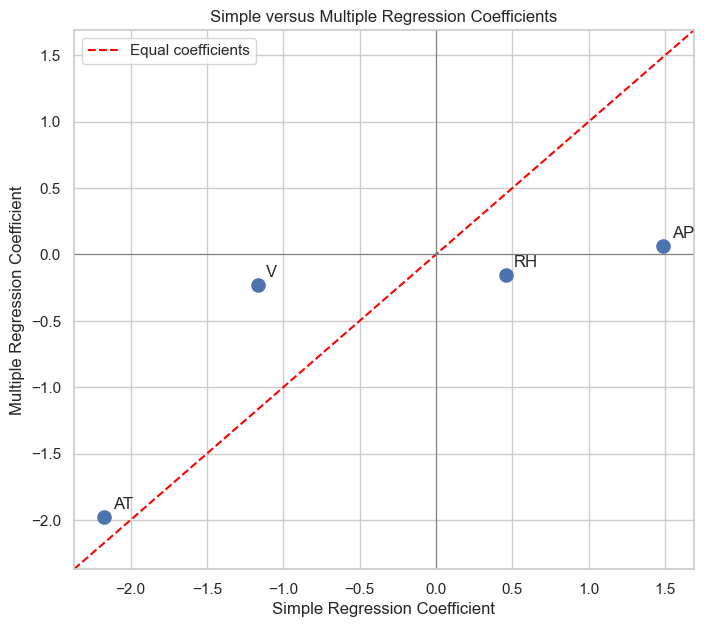

In [29]:
plt.figure(figsize=(8, 7))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    s=90
)

for predictor, row in coefficient_comparison.iterrows():
    plt.annotate(
        predictor,
        (
            row["Simple Regression"],
            row["Multiple Regression"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

limits = [
    coefficient_comparison.to_numpy().min() - 0.2,
    coefficient_comparison.to_numpy().max() + 0.2
]

plt.plot(
    limits,
    limits,
    color="red",
    linestyle="--",
    label="Equal coefficients"
)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

plt.xlim(limits)
plt.ylim(limits)

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple versus Multiple Regression Coefficients")
plt.legend()

plt.show()

**Answer to 1(e):**  

`AT` is close to the red line. Its coefficient changes only slightly
from -2.1713 to -1.9775, so it remains strongly negative in both
models.

`V` is above the red line. Its coefficient changes from -1.1681 to
-0.2339. It remains negative, but its magnitude becomes much smaller
in the multiple regression model.

`AP` is below the red line. Its coefficient decreases from 1.4899 to
0.0621. It remains positive, but its magnitude also becomes much
smaller.

`RH` shows a change in direction. Its coefficient changes from 0.4557
in the simple regression model to -0.1581 in the multiple regression
model. Therefore, its estimated association with `PE` changes from
positive to negative after the other predictors are controlled for.

## 1(f) Nonlinear Associations

For each predictor $X$, fit

$$PE=\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon.$$

Use the p-values of the quadratic and cubic terms to determine whether there is evidence of a nonlinear association.

In [30]:
nonlinear_results = []

for predictor in PREDICTORS:
    polynomial_model = smf.ols(
        f"{RESPONSE} ~ {predictor} "
        f"+ I({predictor} ** 2) "
        f"+ I({predictor} ** 3)",
        data=df
    ).fit()


    quadratic_term = f"I({predictor} ** 2)"
    cubic_term = f"I({predictor} ** 3)"

    _, joint_p_value, _ = polynomial_model.compare_f_test(
    simple_models[predictor]
    )

    nonlinear_results.append({
        "Predictor": predictor,
        "Quadratic P-value":
            polynomial_model.pvalues[quadratic_term],
        "Cubic P-value":
            polynomial_model.pvalues[cubic_term],
        "Joint Nonlinear P-value":
            joint_p_value,
        "R-squared":
            polynomial_model.rsquared
    })

nonlinear_results = pd.DataFrame(
    nonlinear_results
).set_index("Predictor")

display(
    nonlinear_results.style.format({
        "Quadratic P-value": "{:.4e}",
        "Cubic P-value": "{:.4e}",
        "Joint Nonlinear P-value": "{:.4e}",
        "R-squared": "{:.4f}"
    })
)

,Quadratic P-value,Cubic P-value,Joint Nonlinear P-value,R-squared
Predictor,,,,
AT,8.8330e-73,3.6522e-110,3.4784e-285,0.9119
V,7.6850e-01,1.3735e-02,7.0403e-165,0.7750
AP,3.6667e-17,8.2641e-18,3.6468e-19,0.2749
RH,9.3954e-06,1.4403e-05,3.7996e-05,0.1537


**Answer to 1(f):**  

The null hypothesis for the nonlinear terms is

$$
H_0:\beta_2=\beta_3=0.
$$

The joint nonlinear p-values are less than 0.05 for all four
predictors. Therefore, there is statistically significant evidence of
a nonlinear association between each predictor and `PE`.

`AT`: Both quadratic and cubic terms are significant, indicating a clear nonlinear relationship.

`V`: The quadratic term is not significant on its own, but the cubic term is significant, and the joint test of the two nonlinear terms is also significant, so there is still a nonlinear relationship.

`AP`: Both quadratic and cubic terms are significant, indicating a nonlinear relationship.

`RH`: Both quadratic and cubic terms are significant, indicating a nonlinear relationship, but the \(R^2\) is only slightly higher than that of simple regression, so the actual improvement is very small.

## 1(g) Association of interactions of predictors

In [31]:
interaction_formula = (
    f"{RESPONSE} ~ ({' + '.join(PREDICTORS)}) ** 2"
)

interaction_model = smf.ols(
    interaction_formula,
    data=df
).fit()

interaction_terms = [
    f"{PREDICTORS[i]}:{PREDICTORS[j]}"
    for i in range(len(PREDICTORS))
    for j in range(i + 1, len(PREDICTORS))
]

interaction_results = pd.DataFrame({
    "Coefficient":
        interaction_model.params[interaction_terms],
    "P-value":
        interaction_model.pvalues[interaction_terms]
})

interaction_results["Significant at 0.05"] = np.where(
    interaction_results["P-value"] < 0.05,
    "Yes",
    "No"
)

display(
    interaction_results.style.format({
        "Coefficient": "{:.4f}",
        "P-value": "{:.4e}"
    })
)

,Coefficient,P-value,Significant at 0.05
AT:V,0.0210,3.3334e-117,Yes
AT:AP,0.0018,4.5205e-01,No
AT:RH,-0.0052,1.2169e-10,Yes
V:AP,0.0068,2.8770e-07,Yes
V:RH,0.0008,8.6194e-02,No
AP:RH,-0.0016,3.3606e-02,Yes


**Answer to 1(g):**  

The model containing all main effects and pairwise interaction terms
has an \(R^2\) of 0.9363.

At the 0.05 significance level, the following interaction terms are
statistically significant:

- `AT:V`, with \(p<0.001\)
- `AT:RH`, with \(p<0.001\)
- `V:AP`, with \(p<0.001\)
- `AP:RH`, with \(p=0.0336\)

The `AT:AP` interaction is not statistically significant
(\(p=0.4521\)), and the `V:RH` interaction is also not statistically
significant (\(p=0.0862\)).

Therefore, there is evidence that some predictors interact in their
associations with `PE`. For example, the significant `AT:V`
interaction indicates that the estimated association between `AT` and
`PE` depends on the value of `V`.

## 1(h) Model Improvement and MSE Comparison

Randomly split the observations into 70% training data and 30% test data.

Compare:

1. A linear model using all four original predictors.
2. A model containing main effects, all pairwise interactions, and all quadratic terms, followed by removal of insignificant variables using training-set p-values.

Respect model hierarchy: retain the required lower-order terms when keeping interactions or quadratic terms. Report training and test MSE for both models.

In [32]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE
)

main_effects = " + ".join(PREDICTORS)

linear_model = smf.ols(
    f"{RESPONSE} ~ {main_effects}",
    data=train_df
).fit()

linear_train_mse = mean_squared_error(
    train_df[RESPONSE],
    linear_model.predict(train_df)
)

linear_test_mse = mean_squared_error(
    test_df[RESPONSE],
    linear_model.predict(test_df)
)

quadratic_terms = [
    f"I({predictor} ** 2)"
    for predictor in PREDICTORS
]

interaction_terms = [
    f"{PREDICTORS[i]}:{PREDICTORS[j]}"
    for i in range(len(PREDICTORS))
    for j in range(i + 1, len(PREDICTORS))
]

selected_terms = quadratic_terms + interaction_terms

ALPHA = 0.05
elimination_history = []

while True:
    selected_formula = (
        f"{RESPONSE} ~ {main_effects}"
        f" + {' + '.join(selected_terms)}"
    )

    selected_model = smf.ols(
        selected_formula,
        data=train_df
    ).fit()

    higher_order_pvalues = selected_model.pvalues[selected_terms]

    worst_term = higher_order_pvalues.idxmax()
    worst_pvalue = higher_order_pvalues.max()

    if worst_pvalue <= ALPHA:
        break

    elimination_history.append({
        "Removed term": worst_term,
        "P-value": worst_pvalue
    })

    selected_terms.remove(worst_term)

elimination_history = pd.DataFrame(elimination_history)

display(
    elimination_history.style.format({
        "P-value": "{:.4e}"
    })
)

print("Final selected terms:")
print(selected_terms)

,Removed term,P-value
0,V:RH,8.6738e-01
1,I(V ** 2),6.0773e-01
2,V:AP,3.5783e-01


Final selected terms:
['I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


In [33]:
selected_train_mse = mean_squared_error(
    train_df[RESPONSE],
    selected_model.predict(train_df)
)

selected_test_mse = mean_squared_error(
    test_df[RESPONSE],
    selected_model.predict(test_df)
)

mse_comparison = pd.DataFrame({
    "Model": [
        "Linear model",
        "Selected nonlinear and interaction model"
    ],
    "Training MSE": [
        linear_train_mse,
        selected_train_mse
    ],
    "Test MSE": [
        linear_test_mse,
        selected_test_mse
    ]
}).set_index("Model")

display(mse_comparison)

,Training MSE,Test MSE
Model,,
Linear model,20.5808,21.2399
Selected nonlinear and interaction model,17.8908,18.6600


**Answer to 1(h):**

All four main effects were retained to preserve model hierarchy, while
the insignificant higher-order terms `V:RH`, $V^2$, and `V:AP` were
removed.

The selected interaction and quadratic model has lower training and
test MSEs than the four-predictor linear model. Its test MSE is reduced
by approximately 12.15%. Therefore, the selected nonlinear and
interaction terms improve predictive performance on the test data.

## 1(i) KNN

In [34]:
X_train = train_df[PREDICTORS]
X_test = test_df[PREDICTORS]

y_train = train_df[RESPONSE]
y_test = test_df[RESPONSE]

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

feature_sets = {
    "Raw": (X_train, X_test),
    "Normalized": (
        X_train_normalized,
        X_test_normalized
    )
}

knn_results = []

for feature_type, (current_X_train, current_X_test) in feature_sets.items():
    for k in range(1, 101):
        knn_model = KNeighborsRegressor(n_neighbors=k)

        knn_model.fit(current_X_train, y_train)

        knn_results.append({
            "Features": feature_type,
            "k": k,
            "1/k": 1 / k,
            "Training MSE": mean_squared_error(
                y_train,
                knn_model.predict(current_X_train)
            ),
            "Test MSE": mean_squared_error(
                y_test,
                knn_model.predict(current_X_test)
            )
        })

knn_results = pd.DataFrame(knn_results)

best_knn_results = knn_results.loc[
    knn_results.groupby("Features")["Test MSE"].idxmin()
].set_index("Features")

display(best_knn_results)

,k,1/k,Training MSE,Test MSE
Features,,,,
Normalized,4,0.2500,8.5914,14.3057
Raw,5,0.2000,10.6008,15.7268


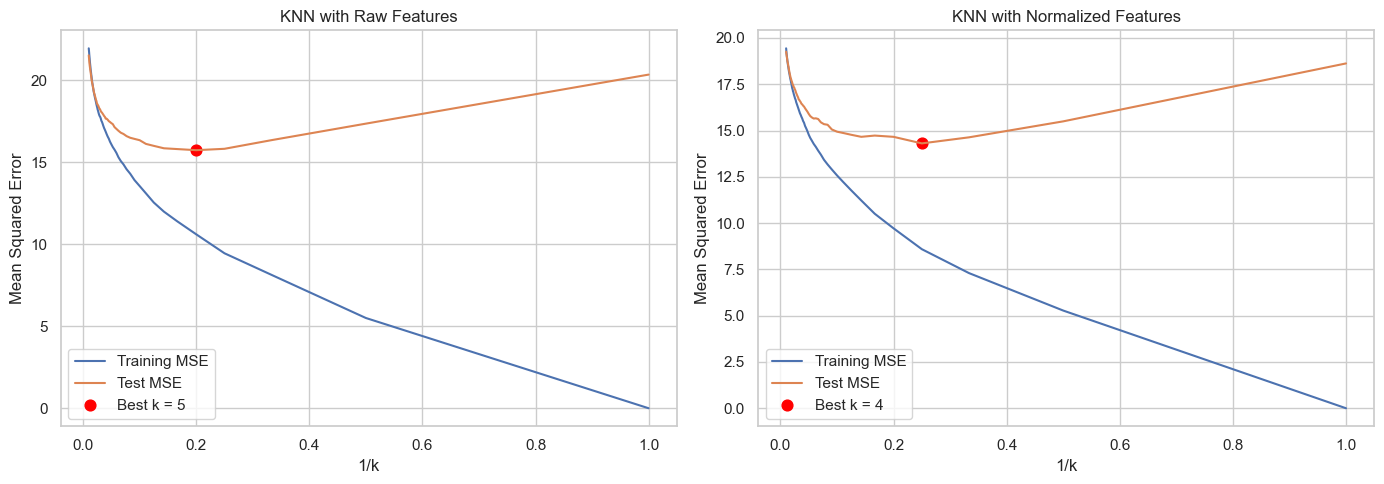

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for feature_type, ax in zip(
    ["Raw", "Normalized"],
    axes
):
    current_results = (
        knn_results[
            knn_results["Features"] == feature_type
        ]
        .sort_values("1/k")
    )

    ax.plot(
        current_results["1/k"],
        current_results["Training MSE"],
        label="Training MSE"
    )

    ax.plot(
        current_results["1/k"],
        current_results["Test MSE"],
        label="Test MSE"
    )

    best_result = best_knn_results.loc[feature_type]

    ax.scatter(
        1 / best_result["k"],
        best_result["Test MSE"],
        color="red",
        s=60,
        label=f"Best k = {int(best_result['k'])}"
    )

    ax.set_title(f"KNN with {feature_type} Features")
    ax.set_xlabel("1/k")
    ax.set_ylabel("Mean Squared Error")
    ax.legend()

plt.tight_layout()
plt.show()

## 1(j) Model Comparison

In [36]:
best_normalized_knn = best_knn_results.loc["Normalized"]

final_comparison = pd.DataFrame({
    "Model": [
        "Selected interaction and quadratic regression",
        f"Normalized KNN (k={int(best_normalized_knn['k'])})"
    ],
    "Training MSE": [
        selected_train_mse,
        best_normalized_knn["Training MSE"]
    ],
    "Test MSE": [
        selected_test_mse,
        best_normalized_knn["Test MSE"]
    ]
}).set_index("Model")

display(final_comparison)

,Training MSE,Test MSE
Model,,
Selected interaction and quadratic regression,17.8908,18.6600
Normalized KNN (k=4),8.5914,14.3057


**Answer to 1(j):**  

The normalized KNN model has the lower test MSE. Compared with the
selected regression model, it reduces the test MSE by approximately
23.34%.

KNN can capture local and nonlinear patterns without specifying
nonlinear and interaction terms in advance, which may explain its
better predictive performance. However, the regression model is easier
to interpret because its coefficients describe the associations between
the predictors and `PE`.

Therefore, normalized KNN provides better predictive performance for
this train/test split, while the regression model provides greater
interpretability.

# 2. ISLR 2.4.1

**Answer to ISLR 2.4.1:**  

| Scenario | Preferred Method | Justification |
|---|---|---|
| (a) The sample size $ n $ is extremely large, while the number of predictors $ p $ is small. | Flexible | With many observations and relatively few predictors, a flexible method has enough data to estimate a complex relationship while limiting the risk of overfitting. Its lower bias may therefore improve test performance. |
| (b) The number of predictors $ p $ is extremely large, while the number of observations $ n $ is small. | Inflexible | With many predictors and few observations, a flexible method is likely to fit noise in the training data. Its high variance may lead to severe overfitting and poor test performance. |
| (c) The relationship between the predictors and the response is highly nonlinear. | Flexible | A flexible method can adapt to a complex nonlinear relationship. An inflexible method may impose an overly simple form and suffer from high bias. |
| (d) The variance of the error terms, $ \sigma^2 = Var(\epsilon) $ , is extremely high. | Inflexible | When the data contain substantial noise, a flexible method may fit the random error rather than the underlying relationship. A less flexible method is less sensitive to noise and is generally less likely to overfit. |

# 3. ISLR 2.4.7

**Answer to ISLR 2.4.7:**  

> | Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$   |
> |------|-------|-------|-------|-------|
> | 1    | 0     | 3     | 0     | Red   |
> | 2    | 2     | 0     | 0     | Red   |
> | 3    | 0     | 1     | 3     | Red   |
> | 4    | 0     | 1     | 2     | Green |
> | 5    | -1    | 0     | 1     | Green |
> | 6    | 1     | 1     | 1     | Red   |

### (a)

The Euclidean distance between an observation
\((X_1,X_2,X_3)\) and the test point \((0,0,0)\) is

$$
d=\sqrt{X_1^2+X_2^2+X_3^2}.
$$

| Observation | Calculation | Distance | Class |
|---:|---|---:|---|
| 1 | $\sqrt{(0^2+3^2+0^2)}$ | 3.0000 | Red |
| 2 | $\sqrt{(2^2+0^2+0^2)}$ | 2.0000 | Red |
| 3 | $\sqrt{(0^2+1^2+3^2)}$ | 3.1623 | Red |
| 4 | $\sqrt{(0^2+1^2+2^2)}$ | 2.2361 | Green |
| 5 | $\sqrt{((-1)^2+0^2+1^2)}$ | 1.4142 | Green |
| 6 | $\sqrt{(1^2+1^2+1^2)}$ | 1.7321 | Red |

### (b)

For $K=1$, the nearest observation is observation 5, whose distance
from the test point is $ 1.4142 $. Because its class is Green, the KNN
prediction is **Green**.

### (c)

For $ K=3 $, the three nearest observations are:

| Observation | Distance | Class |
|---:|---:|---|
| 5 | 1.4142 | Green |
| 6 | 1.7321 | Red |
| 2 | 2.0000 | Red |

Two of the three nearest observations are Red. Therefore, the KNN
prediction is **Red**.

### (d)

If the Bayes decision boundary is highly nonlinear, a relatively small
value of $ K $ is generally preferred. A small $ K $ produces a more
flexible decision boundary that can adapt to local and nonlinear
patterns.

A large $ K $ averages over many observations and produces a smoother,
less flexible boundary, which may fail to capture the nonlinear Bayes
decision boundary.

# References

1. UCI Machine Learning Repository, Combined Cycle Power Plant Data Set.
2. Tüfekci, P. (2014). Prediction of full load electrical power output of a base load operated combined cycle power plant using machine learning methods.
3. Kaya, H., Tüfekci, P., & Gürgen, S. F. (2012). Local and Global Learning Methods for Predicting Power of a Combined Gas & Steam Turbine.